# Completed Jobs: Utilization & Resource Allocation Analysis
Query and analyze `COMPLETED` Slurm jobs directly from Elasticsearch / Kibana indices (`slurm`, `slurm_greatlakes`, `slurm_lighthouse`).

Select a **uniqname**, **subaccount**, or **cluster**, and a completion-date range (default: previous **24 hours**). Multiple supplied filters are combined with AND. Only `COMPLETED` jobs are included; failed, cancelled, and timed-out jobs are excluded.

**Data flow:** Query Elasticsearch cluster → extract job execution & allocation data (runtime, total CPUs, total nodes, allocated core-hours, allocated memory) → summary aggregations and visualizations.

In [21]:
# Run once if needed:
# %pip install requests pandas numpy matplotlib

In [ ]:
import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import requests
import urllib3
from IPython.display import display

# Suppress insecure request warnings for internal ES endpoints if cert verify is disabled
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# INPUTS — set at least one; multiple values narrow the same search.
UNIQNAME = None                 # e.g. "your_uniqname"
SUBACCOUNT = None               # exact Slurm account/subaccount name
CLUSTER = "greatlakes"          # "greatlakes", "armis2", "lighthouse", or None
START = None                    # e.g. "2026-09-13 09:00"; None = END minus 24h
END = None                      # None = now; explicit end is exclusive
TIMEZONE = "America/Detroit"    # used for dates without an explicit timezone

ES_URL = os.getenv("ES_URL", "https://es.arc-ts.umich.edu")
ES_INDICES = "slurm,slurm_greatlakes,slurm_lighthouse"  # indices to search
ES_VERIFY = os.getenv("ES_CA_BUNDLE") or False
PAGE_SIZE = 1000
EXPORT_DIR = Path("completed_job_reports")

In [ ]:
import re

def date_window(start=None, end=None):
    def stamp(value):
        ts = pd.Timestamp(value)
        if ts.tzinfo is None:
            ts = ts.tz_localize(TIMEZONE, ambiguous="raise", nonexistent="raise")
        return ts.tz_convert("UTC")
    end = pd.Timestamp.now(tz="UTC") if end is None else stamp(end)
    start = end - pd.Timedelta(hours=24) if start is None else stamp(start)
    if pd.isna(start) or pd.isna(end) or start >= end:
        raise ValueError("Provide valid dates with START earlier than END.")
    return start, end

def parse_memory_gb(tres_str):
    if not tres_str or pd.isna(tres_str):
        return np.nan
    match = re.search(r'mem=(\d+(?:\.\d+)?)([KMGTP])?', str(tres_str), re.IGNORECASE)
    if not match:
        return np.nan
    val = float(match.group(1))
    unit = (match.group(2) or 'M').upper()
    factors = {'K': 1 / (1024**2), 'M': 1 / 1024, 'G': 1.0, 'T': 1024.0, 'P': 1024.0 * 1024.0}
    return val * factors.get(unit, 1.0)

def build_query(start, end, uniqname=None, subaccount=None, cluster=None):
    values = {"username": uniqname, "account": subaccount, "cluster": cluster}
    values = {k: str(v).strip() for k, v in values.items() if v is not None and str(v).strip()}
    if not values:
        raise ValueError("Set UNIQNAME, SUBACCOUNT or CLUSTER.")
    filters = [{"term": {"state.keyword": "COMPLETED"}},
               {"range": {"@end": {"gte": start.isoformat(), "lt": end.isoformat()}}}]
    filters += [{"term": {key + ".keyword": value}} for key, value in values.items()]
    return {"query": {"bool": {"filter": filters}}, "sort": ["_doc"],
            "_source": ["jobid", "cluster", "username", "account", "job_name", "partition", "state",
                        "@start", "@end", "@submit", "elapsed", "total_cpus", "total_nodes",
                        "tres_alloc", "array_job_id", "array_task_id", "het_job_id", "het_job_offset"]}

es = requests.Session()
if os.getenv("ES_API_KEY"):
    es.headers["Authorization"] = "ApiKey " + os.environ["ES_API_KEY"]
elif os.getenv("ES_USERNAME"):
    es.auth = (os.environ["ES_USERNAME"], os.environ["ES_PASSWORD"])

def es_request(method, path, **kwargs):
    r = es.request(method, ES_URL.rstrip("/") + path, timeout=60, verify=ES_VERIFY, **kwargs)
    r.raise_for_status()
    data = r.json()
    if data.get("timed_out") or data.get("_shards", {}).get("failed", 0):
        raise RuntimeError("Elasticsearch returned incomplete results; retry the query.")
    return data

def fetch_jobs(query):
    rows, scroll_id = [], None
    try:
        page = es_request("POST", f"/{ES_INDICES}/_search", params={"scroll": "3m"},
                          json={**query, "size": PAGE_SIZE})
        while True:
            scroll_id = page.get("_scroll_id", scroll_id)
            hits = page["hits"]["hits"]
            if not hits:
                break
            rows.extend({**h["_source"], "es_index": h["_index"], "es_id": h["_id"]} for h in hits)
            if not scroll_id:
                raise RuntimeError("Missing scroll ID: cannot guarantee complete results.")
            page = es_request("POST", "/_search/scroll", json={"scroll": "3m", "scroll_id": scroll_id})
    finally:
        if scroll_id:
            try:
                es_request("DELETE", "/_search/scroll", json={"scroll_id": [scroll_id]})
            except requests.RequestException:
                warnings.warn("Could not clear scroll; it will expire automatically.")
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    for col in ["@submit", "@start", "@end"]:
        values = df.get(col, pd.Series(index=df.index, dtype=object))
        numeric = values.map(lambda v: isinstance(v, (int, float)) and pd.notna(v))
        dates = pd.to_datetime(values.where(~numeric), utc=True, errors="coerce")
        if numeric.any():
            dates.loc[numeric] = pd.to_datetime(values.loc[numeric], unit="ms", utc=True, errors="coerce")
        df[col] = dates
    for col in ["array_job_id", "array_task_id", "het_job_id", "het_job_offset"]:
        if col not in df:
            df[col] = pd.NA
    keys = ["cluster", "jobid", "@submit", "@start", "array_job_id", "array_task_id", "het_job_id", "het_job_offset"]
    before = len(df)
    df = df.sort_values("@end").drop_duplicates(keys, keep="last").copy()
    print(f"Fetched {before:,} records; {len(df):,} distinct job executions.")
    df["total_cpus"] = pd.to_numeric(df.get("total_cpus", 1), errors="coerce").fillna(1)
    df["total_nodes"] = pd.to_numeric(df.get("total_nodes", 1), errors="coerce").fillna(1)
    df["elapsed_seconds"] = pd.to_numeric(df.get("elapsed", 0), errors="coerce").fillna(0)
    df["runtime_hours"] = df["elapsed_seconds"] / 3600.0
    df["allocated_core_hours"] = df["total_cpus"] * df["runtime_hours"]
    if "tres_alloc" in df:
        df["allocated_mem_gb"] = df["tres_alloc"].apply(parse_memory_gb)
    else:
        df["allocated_mem_gb"] = np.nan
    return df.sort_values("allocated_core_hours", ascending=False).reset_index(drop=True)

In [ ]:
def export_reports(df, summary_df=None, out_dir=EXPORT_DIR):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    stamp = pd.Timestamp.now(tz="UTC").strftime("%Y%m%dT%H%M%SZ")
    all_path = out_dir / f"all_completed_{stamp}.csv"
    df.to_csv(all_path, index=False)
    print(f"Exported {len(df):,} jobs to {all_path}")
    if summary_df is not None and not summary_df.empty:
        summary_path = out_dir / f"summary_{stamp}.csv"
        summary_df.to_csv(summary_path)
        print(f"Exported summary to {summary_path}")

In [ ]:
start, end = date_window(START, END)
query = build_query(start, end, UNIQNAME, SUBACCOUNT, CLUSTER)
print(f"Completion window: {start.tz_convert(TIMEZONE)} to {end.tz_convert(TIMEZONE)} (end exclusive)")
jobs = fetch_jobs(query)
print(f"Total completed jobs: {len(jobs):,}")
if len(jobs):
    print(f"Total allocated core-hours: {jobs['allocated_core_hours'].sum():,.2f}")
    display(jobs.head(10))

Completion window: 2026-09-14 10:48:28.523360-04:00 to 2026-09-15 10:48:28.523360-04:00 (end exclusive)
Fetched 72,247 records; 72,247 distinct job executions.
Statistics cap: 500; jobs are prioritized by allocated core-hours.
Checked 25/500 job reports
Checked 50/500 job reports
Checked 75/500 job reports
Checked 100/500 job reports
Checked 125/500 job reports
Checked 150/500 job reports
Checked 175/500 job reports
Checked 200/500 job reports
Checked 225/500 job reports
Checked 250/500 job reports
Checked 275/500 job reports
Checked 300/500 job reports
Checked 325/500 job reports
Checked 350/500 job reports
Checked 375/500 job reports
Checked 400/500 job reports
Checked 425/500 job reports
Checked 450/500 job reports
Checked 475/500 job reports
Checked 500/500 job reports
Jobs: 72,247


,Jobs
Statistics coverage,
not_requested_cap,71747
ok,497
unavailable: RuntimeError,2
missing_or_invalid_metric,1


CPU measurable: 497; memory measurable: 498


## Ranked Jobs and Group Summaries
Jobs ranked by allocated core-hours, along with aggregated statistics grouped by cluster, account, and user.

In [ ]:
if len(jobs):
    top_cols = ["cluster", "jobid", "username", "account", "job_name", "partition",
                "@start", "@end", "runtime_hours", "total_cpus", "total_nodes",
                "allocated_core_hours", "allocated_mem_gb"]
    display_cols = [c for c in top_cols if c in jobs.columns]
    
    print("Top 20 jobs by allocated core-hours:")
    display(jobs[display_cols].head(20).round(2))
    
    summary = jobs.groupby(["cluster", "account", "username"], dropna=False).agg(
        total_jobs=("jobid", "count"),
        total_core_hours=("allocated_core_hours", "sum"),
        avg_runtime_hours=("runtime_hours", "mean"),
        max_runtime_hours=("runtime_hours", "max"),
        avg_cpus=("total_cpus", "mean"),
        total_mem_gb=("allocated_mem_gb", "sum")
    ).sort_values("total_core_hours", ascending=False)
    
    print("\nResource allocation summary by User and Account:")
    display(summary.round(2))
    
    export_reports(jobs, summary)
else:
    print("No jobs found for the specified query and time range.")

,cluster,jobid,username,account,job_name,@end,total_cpus,cpu_efficiency_pct,memory_efficiency_pct,flag,estimated_idle_core_hours
0,greatlakes,58584373,susannak,xinjunz0,HaplotypeCaller.3,2026-09-15 14:27:15+00:00,16,26.80,33.52,CPU and memory,3269.53
7,greatlakes,61009491,chanyonj,liyues0,ns,2026-09-15 11:12:45+00:00,16,6.28,3.27,CPU and memory,1164.55
9,greatlakes,60997051,lxxiao,jjparkcv_owned1,gts_A_500k,2026-09-15 07:07:32+00:00,16,9.67,53.57,CPU,1031.67
8,greatlakes,61025201,wentaohe,jjparkcv_owned1,lh-padlast-fetch-3phys-v2,2026-09-14 22:12:21+00:00,24,22.54,9.71,CPU and memory,937.68
18,greatlakes,61070706,zhmshi,zhmshi0,tc_estm,2026-09-15 09:13:53+00:00,32,23.18,15.30,CPU and memory,807.83
...,...,...,...,...,...,...,...,...,...,...,...
249,greatlakes,61088925,weishwu,bis1,15999-CV-1.ubam_var,2026-09-14 22:59:45+00:00,12,18.87,100.00,CPU,91.22
273,greatlakes,61111466,chanyonj,liyues0,p_pcfm,2026-09-15 02:06:34+00:00,16,6.23,1.26,CPU and memory,90.30
229,greatlakes,61110247,xwguo,leichn0,MagneticJob,2026-09-15 12:09:12+00:00,8,34.25,60.63,CPU,87.73
263,greatlakes,61108131,srayan,tewaria0,poisson-growing-training,2026-09-15 07:13:49+00:00,8,12.45,9.33,CPU and memory,87.20


completed_jobs  cpu_measured  \
cluster    account       username                                 
greatlakes aaronabk1     aaronabk               2             0   
           abucsek0      yfjin                 22             0   
           adamhelm0     esraaism               1             0   
           adriaens1     shrejj                 1             1   
           agc_project99 jrhemama               2             2   
...                                           ...           ...   
           yunjiang99    almehta                6             2   
           yyusong0      yyusong                2             0   
           zhengya98     minsikky              30             0   
                         mjyun                 31             0   
           zhmshi0       zhmshi                26            25   

                                   memory_measured  low_cpu_jobs  \
cluster    account       username                                  
greatlakes aaronabk1     aaronabk                0             0   
           abucsek0      yfjin                   0             0   
           adamhelm0     esraaism                0             0   
           adriaens1     shrejj                  1             1   
           agc_project99 jrhemama                2             1   
...                                            ...           ...   
           yunjiang99    almehta                 2             0   
           yyusong0      yyusong                 0             0   
           zhengya98     minsikky                0             0   
                         mjyun                   0             0   
           zhmshi0       zhmshi                 25            25   

                                   low_memory_jobs  median_cpu_pct  \
cluster    account       username                                    
greatlakes aaronabk1     aaronabk                0             NaN   
           abucsek0      yfjin                   0             NaN   
           adamhelm0     esraaism                0             NaN   
           adriaens1     shrejj                  0           23.38   
           agc_project99 jrhemama                0           55.32   
...                                            ...             ...   
           yunjiang99    almehta                 0           57.50   
           yyusong0      yyusong                 0             NaN   
           zhengya98     minsikky                0             NaN   
                         mjyun                   0             NaN   
           zhmshi0       zhmshi                 25           21.94   

                                   median_memory_pct  
cluster    account       username                     
greatlakes aaronabk1     aaronabk                NaN  
           abucsek0      yfjin                   NaN  
           adamhelm0     esraaism                NaN  
           adriaens1     shrejj                60.55  
           agc_project99 jrhemama             100.00  
...                                              ...  
           yunjiang99    almehta               81.16  
           yyusong0      yyusong                 NaN  
           zhengya98     minsikky                NaN  
                         mjyun                   NaN  
           zhmshi0       zhmshi                14.84  

[382 rows x 7 columns]

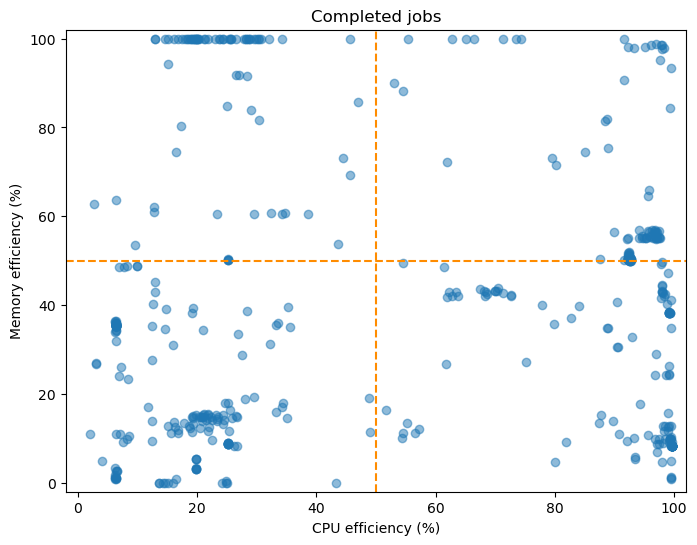

In [ ]:
import matplotlib.pyplot as plt

if len(jobs):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Top users by allocated core-hours
    user_hours = jobs.groupby("username")["allocated_core_hours"].sum().sort_values(ascending=False).head(10)
    user_hours.plot(kind="barh", ax=axes[0], color="steelblue")
    axes[0].set_title("Top Users by Allocated Core-Hours")
    axes[0].set_xlabel("Allocated Core-Hours")
    axes[0].invert_yaxis()
    
    # 2. Job Runtime vs Allocated CPUs
    axes[1].scatter(jobs["runtime_hours"], jobs["total_cpus"], alpha=0.6, color="teal")
    axes[1].set_title("Job Runtime vs Allocated CPUs")
    axes[1].set_xlabel("Runtime (hours)")
    axes[1].set_ylabel("Total CPUs")
    axes[1].set_yscale("log", nonpositive='clip')
    
    plt.tight_layout()
    plt.show()
else:
    print("No data available for plotting.")